# Prepare 2019 Sentinel-1 imagery

This notebook retrieves and mosaics Sentinel-1A SAR imagery for the eastern
slopes of Heard Island. It can run from the beginning on a new machine with
the required Python packages and Copernicus Data Space OAuth credentials.

**Selected acquisition:** 7 April 2019, approximately 00:00:47 UTC;
Sentinel-1A Stripmap, descending, single HH polarisation, relative orbit 4.

**Processing:** terrain-corrected gamma-nought, orthorectified with
Copernicus DEM 30 m, Lee 5 × 5 speckle filter. The output grid is
EPSG:32743 at 10 m pixel spacing. This is output sampling; it does not
imply that all source information has 10 m independent resolution.

The three output bands are HH backscatter in dB, radar shadow mask,
and data mask. Tiles are retained so a failed run can resume without
requesting successful tiles again.

In [16]:
from getpass import getpass
from pathlib import Path
import os
import sys
from pystac_client import Client

gdal_data = Path(sys.prefix) / "Library" / "share" / "gdal"

if (gdal_data / "gdalvrt.xsd").exists():
    os.environ["GDAL_DATA"] = str(gdal_data)

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import requests

from math import ceil, floor
from rasterio.enums import Resampling
from rasterio.merge import merge
from rasterio.warp import transform_bounds
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds

In [2]:
aoi_wgs84 = [73.45, -53.25, 73.85, -52.95]
pixel_size = 10
maximum_tile_pixels = 2400

aoi_utm = transform_bounds(
    "EPSG:4326", "EPSG:32743", *aoi_wgs84, densify_pts = 21)

min_x = int(np.floor(aoi_utm[0] / pixel_size) * pixel_size)
min_y = int(np.floor(aoi_utm[1] / pixel_size) * pixel_size)
max_x = int(np.ceil(aoi_utm[2] / pixel_size) * pixel_size)
max_y = int(np.ceil(aoi_utm[3] / pixel_size) * pixel_size)

full_width = (max_x - min_x) // pixel_size
full_height = (max_y - min_y) // pixel_size

if (full_width, full_height) != (2742, 3389):
    raise RuntimeError(
        f"Unexpected AOI grid: {full_width} × {full_height}")

tile_dir = Path("data/processed/sar_2019_tiles")
tile_dir.mkdir(parents = True, exist_ok = True)

tile_plan = []

for row_start in range(0, full_height, maximum_tile_pixels):
    for column_start in range(0, full_width, maximum_tile_pixels):
        tile_height = min(maximum_tile_pixels, full_height - row_start)
        tile_width = min(maximum_tile_pixels, full_width - column_start)

        tile_min_x = min_x + column_start * pixel_size
        tile_min_y = min_y + row_start * pixel_size
        tile_max_x = tile_min_x + tile_width * pixel_size
        tile_max_y = tile_min_y + tile_height * pixel_size

        tile_name = (
            f"S1A_2019-04-07_RTC_10m_"
            f"r{row_start}_c{column_start}.tif")

        tile_plan.append({
            "path": tile_dir / tile_name,
            "width": tile_width,
            "height": tile_height,
            "bbox": (
                tile_min_x, tile_min_y,
                tile_max_x, tile_max_y)})

print(f"Output grid: {full_width} × {full_height} pixels")
print(f"Planned Process API requests: {len(tile_plan)}")

for tile in tile_plan:
    print(tile["path"].name, tile["width"], "×", tile["height"])

Output grid: 2742 × 3389 pixels
Planned Process API requests: 4
S1A_2019-04-07_RTC_10m_r0_c0.tif 2400 × 2400
S1A_2019-04-07_RTC_10m_r0_c2400.tif 342 × 2400
S1A_2019-04-07_RTC_10m_r2400_c0.tif 2400 × 989
S1A_2019-04-07_RTC_10m_r2400_c2400.tif 342 × 989


In [3]:
missing_tiles = []

for tile in tile_plan:
    tile_path = tile["path"]

    if not tile_path.exists():
        missing_tiles.append(tile)
        continue

    try:
        with rasterio.open(tile_path) as source:
            actual_size = (source.width, source.height, source.count)
            expected_size = (tile["width"], tile["height"], 3)

            if actual_size != expected_size:
                raise ValueError(
                    f"Expected {expected_size}, found {actual_size}")

            if source.crs.to_epsg() != 32743:
                raise ValueError(f"Unexpected CRS: {source.crs}")

            if not np.allclose(source.res, (10, 10)):
                raise ValueError(f"Unexpected resolution: {source.res}")

            if not np.allclose(
                source.bounds, tile["bbox"], rtol = 0, atol = 0.01):
                raise ValueError("Tile bounds do not match the grid")

            source.read(1, window = ((0, 16), (0, 16)))
    except (rasterio.errors.RasterioIOError, ValueError) as error:
        raise RuntimeError(
            f"Existing tile needs attention: {tile_path}") from error

    print("Reusing:", tile_path.name)

print(f"Tiles to download: {len(missing_tiles)}")

Reusing: S1A_2019-04-07_RTC_10m_r0_c0.tif
Reusing: S1A_2019-04-07_RTC_10m_r0_c2400.tif
Reusing: S1A_2019-04-07_RTC_10m_r2400_c0.tif
Reusing: S1A_2019-04-07_RTC_10m_r2400_c2400.tif
Tiles to download: 0


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\2332477683.py:29: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 16), (0, 16)))


In [4]:
evalscript = """
//VERSION=3

function setup() {
    return {
        input: ["HH", "shadowMask", "dataMask"],
        output: {
            id: "default",
            bands: 3,
            sampleType: "FLOAT32"
        }
    }
}

function evaluatePixel(sample) {
    let hhDb = sample.HH > 0
        ? 10 * Math.log(sample.HH) / Math.LN10
        : -99;

    return [hhDb, sample.shadowMask, sample.dataMask];
}
"""

if missing_tiles:
    client_id = getpass("Copernicus client ID: ").strip()
    client_secret = getpass("Copernicus client secret: ").strip()

    if not client_id or not client_secret:
        raise ValueError("Both OAuth credentials are required")

    token_url = (
        "https://identity.dataspace.copernicus.eu/auth/realms/"
        "CDSE/protocol/openid-connect/token")

    token_response = requests.post(
        token_url,
        data = {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret},
        timeout = (30, 30))

    del client_id, client_secret

    if not token_response.ok:
        raise RuntimeError(
            f"Authentication failed ({token_response.status_code}): "
            f"{token_response.text[:300]}")

    access_token = token_response.json()["access_token"]

    for tile in missing_tiles:
        request_body = {
            "input": {
                "bounds": {
                    "bbox": list(tile["bbox"]),
                    "properties": {
                        "crs": (
                            "http://www.opengis.net/def/crs/"
                            "EPSG/0/32743")}},
                "data": [{
                    "type": "sentinel-1-grd",
                    "dataFilter": {
                        "timeRange": {
                            "from": "2019-04-07T00:00:00Z",
                            "to": "2019-04-07T00:02:00Z"},
                        "acquisitionMode": "SM",
                        "polarization": "SH",
                        "orbitDirection": "DESCENDING",
                        "resolution": "HIGH"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS_30",
                        "radiometricTerrainOversampling": 3,
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 5,
                            "windowSizeY": 5}}}]},
            "output": {
                "width": tile["width"],
                "height": tile["height"],
                "responses": [{
                    "identifier": "default",
                    "format": {"type": "image/tiff"}}]},
            "evalscript": evalscript}

        print("Requesting:", tile["path"].name, flush = True)

        response = requests.post(
            "https://sh.dataspace.copernicus.eu/process/v1",
            headers = {
                "Authorization": f"Bearer {access_token}",
                "Accept": "image/tiff"},
            json = request_body,
            timeout = (30, 300))

        if not response.ok:
            raise RuntimeError(
                f"Tile request failed ({response.status_code}): "
                f"{response.text[:1000]}")

        temporary_path = tile["path"].with_suffix(".partial.tif")
        temporary_path.write_bytes(response.content)

        with rasterio.open(temporary_path) as source:
            actual_size = (source.width, source.height, source.count)
            expected_size = (tile["width"], tile["height"], 3)

            if actual_size != expected_size:
                raise ValueError(
                    f"{temporary_path.name}: expected {expected_size}, "
                    f"found {actual_size}")

            if source.crs.to_epsg() != 32743:
                raise ValueError(
                    f"{temporary_path.name}: unexpected CRS")

            if not np.allclose(
                source.bounds, tile["bbox"], rtol = 0, atol = 0.01):
                raise ValueError(
                    f"{temporary_path.name}: unexpected bounds")

            source.read(1, window = ((0, 16), (0, 16)))

        temporary_path.replace(tile["path"])
        print("Downloaded:", tile["path"].name)

    del access_token
else:
    print("All four tiles are present; no authentication or API requests.")

All four tiles are present; no authentication or API requests.


In [6]:
tile_paths = [tile["path"] for tile in tile_plan]
output_path = Path("data/processed/S1A_HH_2019-04-07_RTC_10m.tif")
temporary_output = output_path.with_name(
    f"{output_path.stem}_building.tif")

temporary_output.unlink(missing_ok = True)

print("Writing mosaic in chunks...", flush = True)

merge(
    tile_paths,
    dst_path = temporary_output,
    mem_limit = 64,
    dst_kwds = {
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER"})

with rasterio.open(temporary_output, "r+") as mosaic:
    shape = (mosaic.count, mosaic.height, mosaic.width)

    if shape != (3, full_height, full_width):
        raise RuntimeError(f"Unexpected mosaic shape: {shape}")

    if mosaic.crs.to_epsg() != 32743:
        raise RuntimeError(f"Unexpected CRS: {mosaic.crs}")

    if not np.allclose(
        mosaic.bounds, (min_x, min_y, max_x, max_y),
        rtol = 0, atol = 0.01):
        raise RuntimeError("Mosaic bounds do not match the planned grid")

    mosaic.set_band_description(1, "HH backscatter (dB)")
    mosaic.set_band_description(2, "Radar shadow mask")
    mosaic.set_band_description(3, "Data mask")

    print("Shape:", shape)
    print("Resolution:", mosaic.res)
    print("Internal blocks:", mosaic.block_shapes[0])

os.replace(temporary_output, output_path)
print("Completed:", output_path)

Writing mosaic in chunks...
Shape: (3, 3389, 2742)
Resolution: (10.0, 10.0)
Internal blocks: (256, 256)
Completed: data\processed\S1A_HH_2019-04-07_RTC_10m.tif


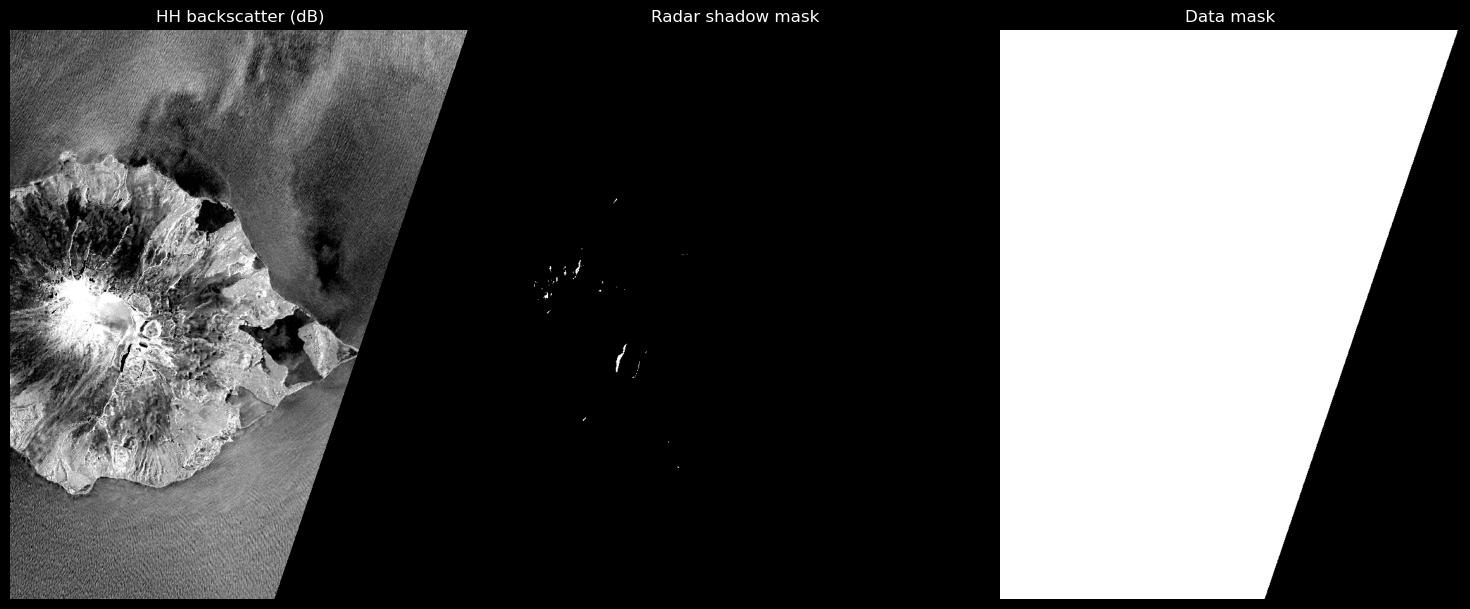

Unshadowed valid preview pixels: 78.3%


In [7]:
with rasterio.open(output_path) as source:
    preview_height = min(900, source.height)
    preview_width = round(
        source.width * preview_height / source.height)

    preview = source.read(
        out_shape = (3, preview_height, preview_width),
        resampling = Resampling.nearest)

hh_db, shadow_mask, data_mask = preview

valid = (
    (data_mask > 0.5)
    & (shadow_mask < 0.5)
    & (hh_db > -99)
    & np.isfinite(hh_db))

if not np.any(valid):
    raise RuntimeError("No unshadowed valid pixels in the preview")

lower, upper = np.percentile(hh_db[valid], [2, 98])

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 3, figsize = (15, 6))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh_db),
        cmap = "gray", vmin = lower, vmax = upper)
    axes[0].set_title("HH backscatter (dB)")

    axes[1].imshow(
        shadow_mask, cmap = "gray", vmin = 0, vmax = 1)
    axes[1].set_title("Radar shadow mask")

    axes[2].imshow(
        data_mask, cmap = "gray", vmin = 0, vmax = 1)
    axes[2].set_title("Data mask")

    for ax in axes:
        ax.axis("off")

    fig.tight_layout()
    plt.show()

print(f"Unshadowed valid preview pixels: {valid.mean():.1%}")

In [11]:
heard_bounds = (73.2, -53.2, 73.9667, -52.9333)
grid_width, grid_height = 750, 300

catalog = Client.open("https://stac.dataspace.copernicus.eu/v1/")

search = catalog.search(
    collections = ["sentinel-1-grd"],
    bbox = heard_bounds,
    datetime = "2019-04-06T00:00:00Z/2019-04-06T23:59:59Z",
    method = "GET",
    limit = 10,
    max_items = 20)

iw_items = [
    item for item in search.items()
    if item.id.startswith("S1A_IW_") and "_1SSH_" in item.id]

if not iw_items:
    raise RuntimeError("No 6 April 2019 IW HH scene found")

grid_transform = from_bounds(
    *heard_bounds, grid_width, grid_height)

for item in iw_items:
    footprint = geometry_mask(
        [item.geometry],
        out_shape = (grid_height, grid_width),
        transform = grid_transform,
        invert = True)

    print(item.id)
    print(f"Coverage of map rectangle: {footprint.mean():.1%}")


S1A_IW_GRDH_1SSH_20190406T142730_20190406T142755_026670_02FE32_F3EE_COG
Coverage of map rectangle: 92.4%
S1A_IW_GRDH_1SSH_20190406T142730_20190406T142755_026670_02FE32_B6A4_COG
Coverage of map rectangle: 92.4%


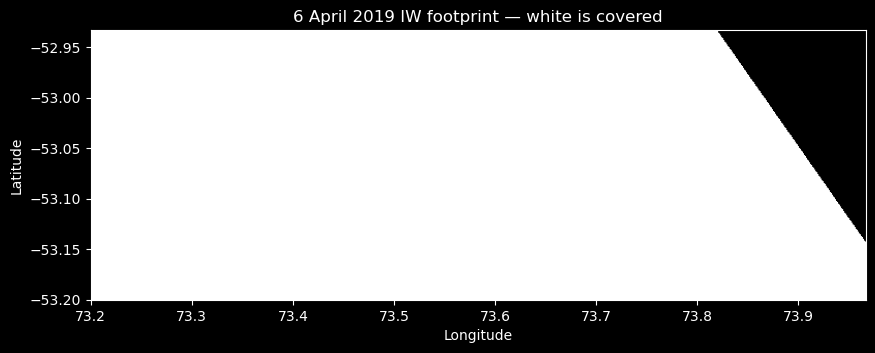

In [12]:
## Plot the 2019 IW footprint

# Matplotlib expects west, east, south, north.
plot_extent = (
    heard_bounds[0], heard_bounds[2],
    heard_bounds[1], heard_bounds[3])

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize = (10, 5))
    ax.imshow(
        footprint,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    ax.set(
        title = "6 April 2019 IW footprint — white is covered",
        xlabel = "Longitude",
        ylabel = "Latitude")
    plt.show()

In [15]:
## Rank full-island Sentinel-1 footprints

# Compare acquisition footprints without downloading imagery.
periods = {
    "2019": "2019-03-01/2019-04-30",
    "2026": "2026-03-01/2026-04-30"}

for year, date_range in periods.items():
    search = catalog.search(
        collections = ["sentinel-1-grd"],
        bbox = heard_bounds,
        datetime = date_range,
        method = "GET",
        limit = 50,
        max_items = 100)

    candidates = []
    seen = set()

    for item in search.items():
        # Collapse duplicate COGs of the same acquisition and footprint.
        key = (
            item.datetime,
            item.properties.get("sar:instrument_mode"),
            tuple(item.properties.get("sar:polarizations", [])),
            tuple(item.bbox))

        if key in seen:
            continue

        seen.add(key)

        footprint = geometry_mask(
            [item.geometry],
            out_shape = (grid_height, grid_width),
            transform = grid_transform,
            invert = True)

        candidates.append((footprint.mean(), item))

    print(f"\n{year}: {len(candidates)} distinct footprints")

    for coverage, item in sorted(candidates, reverse = True, key = lambda row: row[0])[:10]:
        mode = item.properties.get("sar:instrument_mode")
        pol = item.properties.get("sar:polarizations")
        orbit = item.properties.get("sat:relative_orbit")

        print(
            f"{coverage:.1%}  {item.datetime:%Y-%m-%d %H:%M}  "
            f"{mode}  {pol}  orbit {orbit}  {item.id}")


2019: 26 distinct footprints
100.0%  2019-04-25 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190425T141918_20190425T141947_026947_030845_057E_COG
100.0%  2019-04-13 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190413T141917_20190413T141946_026772_0301F3_1036_COG
100.0%  2019-04-01 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190401T141917_20190401T141946_026597_02FB8B_DA6E_COG
100.0%  2019-03-20 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190320T141916_20190320T141945_026422_02F516_81F5_COG
100.0%  2019-03-08 14:19  IW  ['HH']  orbit 100  S1A_IW_GRDH_1SSH_20190308T141916_20190308T141945_026247_02EEA3_EDE4_COG
92.8%  2019-03-13 14:27  IW  ['HH']  orbit 173  S1A_IW_GRDH_1SSH_20190313T142729_20190313T142754_026320_02F14B_9B72_COG
92.8%  2019-03-13 14:27  IW  ['HH']  orbit 173  S1A_IW_GRDH_1SSH_20190313T142729_20190313T142754_026320_02F14B_98BA_COG
92.7%  2019-03-01 14:27  IW  ['HH']  orbit 173  S1A_IW_GRDH_1SSH_20190301T142729_20190301T142754_026145_02EAE9_1DE6_COG
92.7%

In [17]:
## Set the matched full-island SAR grid

# Both scenes use IW, HH, ascending orbit 100.
scene_dates = {
    2019: "2019-04-13",
    2026: "2026-04-12"}

# Include a margin around the AAD Heard Island map extent.
full_aoi_wgs84 = (73.18, -53.22, 73.99, -52.91)
pixel_size = 10
maximum_tile_pixels = 2400

min_x, min_y, max_x, max_y = transform_bounds(
    "EPSG:4326",
    "EPSG:32743",
    *full_aoi_wgs84,
    densify_pts = 21)

min_x = floor(min_x / pixel_size) * pixel_size
min_y = floor(min_y / pixel_size) * pixel_size
max_x = ceil(max_x / pixel_size) * pixel_size
max_y = ceil(max_y / pixel_size) * pixel_size

full_width = int((max_x - min_x) / pixel_size)
full_height = int((max_y - min_y) / pixel_size)

tile_count = (
    ceil(full_width / maximum_tile_pixels)
    * ceil(full_height / maximum_tile_pixels))

print("Scenes:", scene_dates)
print(f"Full-island grid: {full_width} × {full_height} pixels")
print(f"Tiles per scene: {tile_count}")

Scenes: {2019: '2019-04-13', 2026: '2026-04-12'}
Full-island grid: 5496 × 3557 pixels
Tiles per scene: 6


In [18]:
## Download full-island 2019 IW tiles

scene_date = scene_dates[2019]
tile_dir = Path("data/processed/sar_2019_iw_tiles")
tile_dir.mkdir(parents = True, exist_ok = True)

# Keep the same three bands as the Stripmap trial.
evalscript = """
//VERSION=3

function setup() {
    return {
        input: ["HH", "shadowMask", "dataMask"],
        output: {
            id: "default",
            bands: 3,
            sampleType: "FLOAT32"
        }
    }
}

function evaluatePixel(sample) {
    let hhDb = sample.HH > 0
        ? 10 * Math.log(sample.HH) / Math.LN10
        : -99;

    return [hhDb, sample.shadowMask, sample.dataMask];
}
"""

def valid_tile(path, width, height):
    if not path.exists() or path.stat().st_size < 1024:
        return False

    try:
        with rasterio.open(path) as source:
            if (
                source.width != width
                or source.height != height
                or source.count != 3
                or source.crs.to_epsg() != 32743
            ):
                return False

            source.read(1, window = ((0, 1), (0, 1)))
            return True
    except (rasterio.errors.RasterioIOError, OSError):
        return False

# Prepare the six tile bounds on the shared 10 m grid.
tile_specs = []

for row_start in range(0, full_height, maximum_tile_pixels):
    for column_start in range(0, full_width, maximum_tile_pixels):
        tile_height = min(
            maximum_tile_pixels, full_height - row_start)
        tile_width = min(
            maximum_tile_pixels, full_width - column_start)

        tile_min_x = min_x + column_start * pixel_size
        tile_min_y = min_y + row_start * pixel_size

        tile_bounds = [
            tile_min_x,
            tile_min_y,
            tile_min_x + tile_width * pixel_size,
            tile_min_y + tile_height * pixel_size]

        tile_path = tile_dir / (
            f"S1A_IW_HH_{scene_date}_RTC_10m_"
            f"r{row_start}_c{column_start}.tif")

        tile_specs.append((
            tile_path, tile_width, tile_height, tile_bounds))

missing_tiles = [
    spec for spec in tile_specs
    if not valid_tile(spec[0], spec[1], spec[2])]

print(f"Valid tiles: {len(tile_specs) - len(missing_tiles)} of {len(tile_specs)}")
print(f"Tiles to download: {len(missing_tiles)}")

if missing_tiles:
    # Credentials are requested only when a download is needed.
    client_id = getpass("Copernicus client ID: ").strip()
    client_secret = getpass("Copernicus client secret: ").strip()

    if not client_id or not client_secret:
        raise ValueError("Both credentials are required")

    token_response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/"
        "realms/CDSE/protocol/openid-connect/token",
        data = {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret},
        timeout = 30)

    if not token_response.ok:
        raise RuntimeError(
            f"Authentication failed ({token_response.status_code}): "
            f"{token_response.text[:300]}")

    access_token = token_response.json()["access_token"]
    del client_secret

    for tile_path, tile_width, tile_height, tile_bounds in missing_tiles:
        request_body = {
            "input": {
                "bounds": {
                    "bbox": tile_bounds,
                    "properties": {
                        "crs": (
                            "http://www.opengis.net/def/crs/"
                            "EPSG/0/32743")}},
                "data": [{
                    "type": "sentinel-1-grd",
                    "dataFilter": {
                        "timeRange": {
                            "from": f"{scene_date}T14:19:00Z",
                            "to": f"{scene_date}T14:20:00Z"},
                        "acquisitionMode": "IW",
                        "polarization": "SH",
                        "orbitDirection": "ASCENDING",
                        "resolution": "HIGH"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS_30",
                        "radiometricTerrainOversampling": 3,
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 5,
                            "windowSizeY": 5}}}]},
            "output": {
                "width": tile_width,
                "height": tile_height,
                "responses": [{
                    "identifier": "default",
                    "format": {
                        "type": "image/tiff"}}]},
            "evalscript": evalscript}

        # Write to a temporary TIFF so an interrupted download
        # cannot masquerade as a completed tile.
        temporary_tile = tile_path.with_name(
            f"{tile_path.stem}_building.tif")
        temporary_tile.unlink(missing_ok = True)

        print("Downloading:", tile_path.name, flush = True)

        with requests.post(
            "https://sh.dataspace.copernicus.eu/process/v1",
            headers = {
                "Authorization": f"Bearer {access_token}",
                "Content-Type": "application/json",
                "Accept": "image/tiff"},
            json = request_body,
            stream = True,
            timeout = (30, 300)) as response:

            if not response.ok:
                raise RuntimeError(
                    f"Tile failed ({response.status_code}): "
                    f"{response.text[:500]}")

            with temporary_tile.open("wb") as output:
                for chunk in response.iter_content(
                    chunk_size = 1024 * 1024
                ):
                    if chunk:
                        output.write(chunk)

        if not valid_tile(
            temporary_tile, tile_width, tile_height
        ):
            raise RuntimeError(
                f"Downloaded tile failed validation: {tile_path.name}")

        temporary_tile.replace(tile_path)
        print("Saved:", tile_path.name, flush = True)

print("Valid final tiles:", sum(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs))

Valid tiles: 0 of 6
Tiles to download: 6
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r0_c0.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r0_c0.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r0_c2400.tif


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\3362925263.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 1), (0, 1)))


Saved: S1A_IW_HH_2019-04-13_RTC_10m_r0_c2400.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r0_c4800.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r0_c4800.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c0.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c0.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c2400.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c2400.tif
Downloading: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c4800.tif
Saved: S1A_IW_HH_2019-04-13_RTC_10m_r2400_c4800.tif
Valid final tiles: 6


In [19]:
## Mosaic the full-island 2019 IW tiles

# Check the six inputs before writing a new mosaic.
tile_paths = [spec[0] for spec in tile_specs]

if not all(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs
):
    raise RuntimeError("One or more 2019 IW tiles are missing or invalid")

output_path = Path(
    "data/processed/S1A_IW_HH_2019-04-13_RTC_10m.tif")
temporary_output = output_path.with_name(
    f"{output_path.stem}_building.tif")

# A previous interrupted mosaic may have left a damaged TIFF.
temporary_output.unlink(missing_ok = True)

print("Writing full-island mosaic in chunks...", flush = True)

merge(
    tile_paths,
    dst_path = temporary_output,
    mem_limit = 64,
    dst_kwds = {
        "driver": "GTiff",
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER"})

with rasterio.open(temporary_output, "r+") as mosaic:
    shape = (mosaic.count, mosaic.height, mosaic.width)

    if shape != (3, full_height, full_width):
        raise RuntimeError(f"Unexpected mosaic shape: {shape}")

    mosaic.set_band_description(1, "HH backscatter (dB)")
    mosaic.set_band_description(2, "Radar shadow mask")
    mosaic.set_band_description(3, "Data mask")

temporary_output.replace(output_path)

print("Saved:", output_path)
print("Shape:", shape)

Writing full-island mosaic in chunks...


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\3362925263.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 1), (0, 1)))


Saved: data\processed\S1A_IW_HH_2019-04-13_RTC_10m.tif
Shape: (3, 3557, 5496)


Valid data in AOI: 100.0%
Radar shadow within valid data: 0.2%


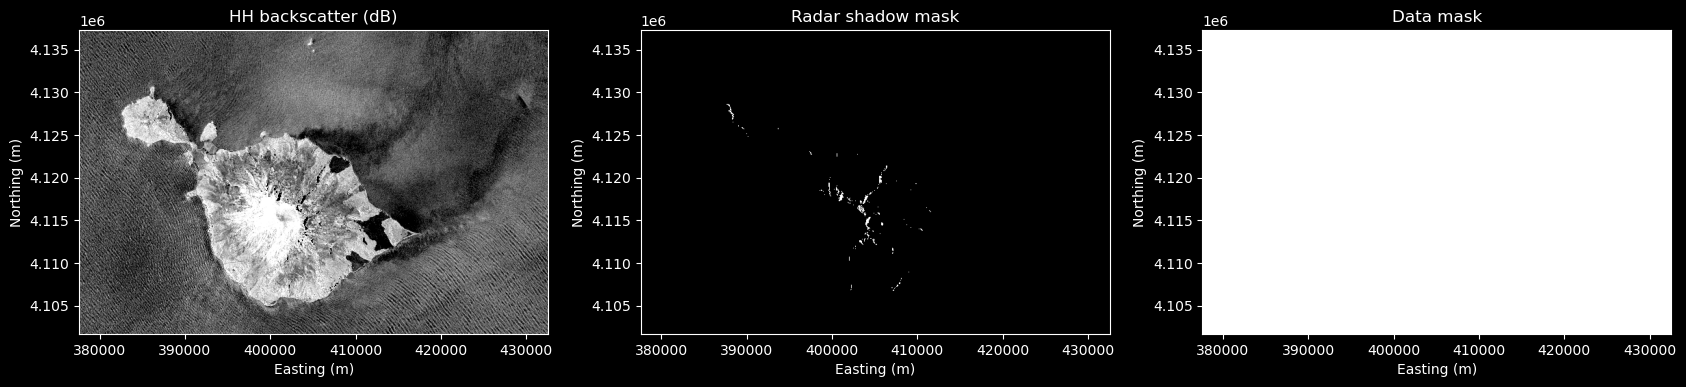

In [20]:
## Preview the full-island 2019 IW mosaic

# Read a reduced preview rather than the full raster into memory.
with rasterio.open(output_path) as source:
    preview_height = max(1, source.height // 8)
    preview_width = max(1, source.width // 8)

    preview = source.read(
        out_shape = (3, preview_height, preview_width))

    plot_extent = (
        source.bounds.left,
        source.bounds.right,
        source.bounds.bottom,
        source.bounds.top)

hh, shadow, data = preview
valid = data > 0.5

if not valid.any():
    raise RuntimeError("The mosaic contains no valid data")

hh_values = hh[valid & np.isfinite(hh) & (hh > -90)]
vmin, vmax = np.percentile(hh_values, [2, 98])

print(f"Valid data in AOI: {valid.mean():.1%}")
print(f"Radar shadow within valid data: {(shadow[valid] > 0.5).mean():.1%}")

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 3, figsize = (17, 6))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh),
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = vmin,
        vmax = vmax)
    axes[0].set_title("HH backscatter (dB)")

    axes[1].imshow(
        shadow,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[1].set_title("Radar shadow mask")

    axes[2].imshow(
        valid,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[2].set_title("Data mask")

    for ax in axes:
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    fig.tight_layout()
    plt.show()

## 2026 

In [21]:
## Download full-island 2026 IW tiles

scene_date = scene_dates[2026]
tile_dir = Path("data/processed/sar_2026_iw_tiles")
tile_dir.mkdir(parents = True, exist_ok = True)

# Keep the same three bands as the Stripmap trial.
evalscript = """
//VERSION=3

function setup() {
    return {
        input: ["HH", "shadowMask", "dataMask"],
        output: {
            id: "default",
            bands: 3,
            sampleType: "FLOAT32"
        }
    }
}

function evaluatePixel(sample) {
    let hhDb = sample.HH > 0
        ? 10 * Math.log(sample.HH) / Math.LN10
        : -99;

    return [hhDb, sample.shadowMask, sample.dataMask];
}
"""

def valid_tile(path, width, height):
    if not path.exists() or path.stat().st_size < 1024:
        return False

    try:
        with rasterio.open(path) as source:
            if (
                source.width != width
                or source.height != height
                or source.count != 3
                or source.crs.to_epsg() != 32743
            ):
                return False

            source.read(1, window = ((0, 1), (0, 1)))
            return True
    except (rasterio.errors.RasterioIOError, OSError):
        return False

# Prepare the six tile bounds on the shared 10 m grid.
tile_specs = []

for row_start in range(0, full_height, maximum_tile_pixels):
    for column_start in range(0, full_width, maximum_tile_pixels):
        tile_height = min(
            maximum_tile_pixels, full_height - row_start)
        tile_width = min(
            maximum_tile_pixels, full_width - column_start)

        tile_min_x = min_x + column_start * pixel_size
        tile_min_y = min_y + row_start * pixel_size

        tile_bounds = [
            tile_min_x,
            tile_min_y,
            tile_min_x + tile_width * pixel_size,
            tile_min_y + tile_height * pixel_size]

        tile_path = tile_dir / (
            f"S1A_IW_HH_{scene_date}_RTC_10m_"
            f"r{row_start}_c{column_start}.tif")

        tile_specs.append((
            tile_path, tile_width, tile_height, tile_bounds))

missing_tiles = [
    spec for spec in tile_specs
    if not valid_tile(spec[0], spec[1], spec[2])]

print(f"Valid tiles: {len(tile_specs) - len(missing_tiles)} of {len(tile_specs)}")
print(f"Tiles to download: {len(missing_tiles)}")

if missing_tiles:
    # Credentials are requested only when a download is needed.
    client_id = getpass("Copernicus client ID: ").strip()
    client_secret = getpass("Copernicus client secret: ").strip()

    if not client_id or not client_secret:
        raise ValueError("Both credentials are required")

    token_response = requests.post(
        "https://identity.dataspace.copernicus.eu/auth/"
        "realms/CDSE/protocol/openid-connect/token",
        data = {
            "grant_type": "client_credentials",
            "client_id": client_id,
            "client_secret": client_secret},
        timeout = 30)

    if not token_response.ok:
        raise RuntimeError(
            f"Authentication failed ({token_response.status_code}): "
            f"{token_response.text[:300]}")

    access_token = token_response.json()["access_token"]
    del client_secret

    for tile_path, tile_width, tile_height, tile_bounds in missing_tiles:
        request_body = {
            "input": {
                "bounds": {
                    "bbox": tile_bounds,
                    "properties": {
                        "crs": (
                            "http://www.opengis.net/def/crs/"
                            "EPSG/0/32743")}},
                "data": [{
                    "type": "sentinel-1-grd",
                    "dataFilter": {
                        "timeRange": {
                            "from": f"{scene_date}T14:19:00Z",
                            "to": f"{scene_date}T14:20:00Z"},
                        "acquisitionMode": "IW",
                        "polarization": "SH",
                        "orbitDirection": "ASCENDING",
                        "resolution": "HIGH"},
                    "processing": {
                        "backCoeff": "GAMMA0_TERRAIN",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS_30",
                        "radiometricTerrainOversampling": 3,
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 5,
                            "windowSizeY": 5}}}]},
            "output": {
                "width": tile_width,
                "height": tile_height,
                "responses": [{
                    "identifier": "default",
                    "format": {
                        "type": "image/tiff"}}]},
            "evalscript": evalscript}

        # Write to a temporary TIFF so an interrupted download
        # cannot masquerade as a completed tile.
        temporary_tile = tile_path.with_name(
            f"{tile_path.stem}_building.tif")
        temporary_tile.unlink(missing_ok = True)

        print("Downloading:", tile_path.name, flush = True)

        with requests.post(
            "https://sh.dataspace.copernicus.eu/process/v1",
            headers = {
                "Authorization": f"Bearer {access_token}",
                "Content-Type": "application/json",
                "Accept": "image/tiff"},
            json = request_body,
            stream = True,
            timeout = (30, 300)) as response:

            if not response.ok:
                raise RuntimeError(
                    f"Tile failed ({response.status_code}): "
                    f"{response.text[:500]}")

            with temporary_tile.open("wb") as output:
                for chunk in response.iter_content(
                    chunk_size = 1024 * 1024
                ):
                    if chunk:
                        output.write(chunk)

        if not valid_tile(
            temporary_tile, tile_width, tile_height
        ):
            raise RuntimeError(
                f"Downloaded tile failed validation: {tile_path.name}")

        temporary_tile.replace(tile_path)
        print("Saved:", tile_path.name, flush = True)

print("Valid final tiles:", sum(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs))

Valid tiles: 0 of 6
Tiles to download: 6
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r0_c0.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r0_c0.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r0_c2400.tif


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\2390828930.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 1), (0, 1)))


Saved: S1A_IW_HH_2026-04-12_RTC_10m_r0_c2400.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r0_c4800.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r0_c4800.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c0.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c0.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c2400.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c2400.tif
Downloading: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c4800.tif
Saved: S1A_IW_HH_2026-04-12_RTC_10m_r2400_c4800.tif
Valid final tiles: 6


In [ ]:
## Mosaic the full-island 2026 IW tiles

# Check the six inputs before writing a new mosaic.
tile_paths = [spec[0] for spec in tile_specs]

if not all(
    valid_tile(path, width, height)
    for path, width, height, _ in tile_specs
):
    raise RuntimeError("One or more 2026 IW tiles are missing or invalid")

output_path = Path(
    "data/processed/S1A_IW_HH_2026-04-12_RTC_10m.tif")
temporary_output = output_path.with_name(
    f"{output_path.stem}_building.tif")

# A previous interrupted mosaic may have left a damaged TIFF.
temporary_output.unlink(missing_ok = True)

print("Writing full-island mosaic in chunks...", flush = True)

merge(
    tile_paths,
    dst_path = temporary_output,
    mem_limit = 64,
    dst_kwds = {
        "driver": "GTiff",
        "compress": "deflate",
        "predictor": 3,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "BIGTIFF": "IF_SAFER"})

with rasterio.open(temporary_output, "r+") as mosaic:
    shape = (mosaic.count, mosaic.height, mosaic.width)

    if shape != (3, full_height, full_width):
        raise RuntimeError(f"Unexpected mosaic shape: {shape}")

    mosaic.set_band_description(1, "HH backscatter (dB)")
    mosaic.set_band_description(2, "Radar shadow mask")
    mosaic.set_band_description(3, "Data mask")

temporary_output.replace(output_path)

print("Saved:", output_path)
print("Shape:", shape)

Writing full-island mosaic in chunks...


C:\Users\harry\AppData\Local\Temp\ipykernel_41064\2390828930.py:45: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  source.read(1, window = ((0, 1), (0, 1)))


Saved: data\processed\S1A_IW_HH_2026-04-12_RTC_10m.tif
Shape: (3, 3557, 5496)


Valid data in AOI: 100.0%
Radar shadow within valid data: 0.2%


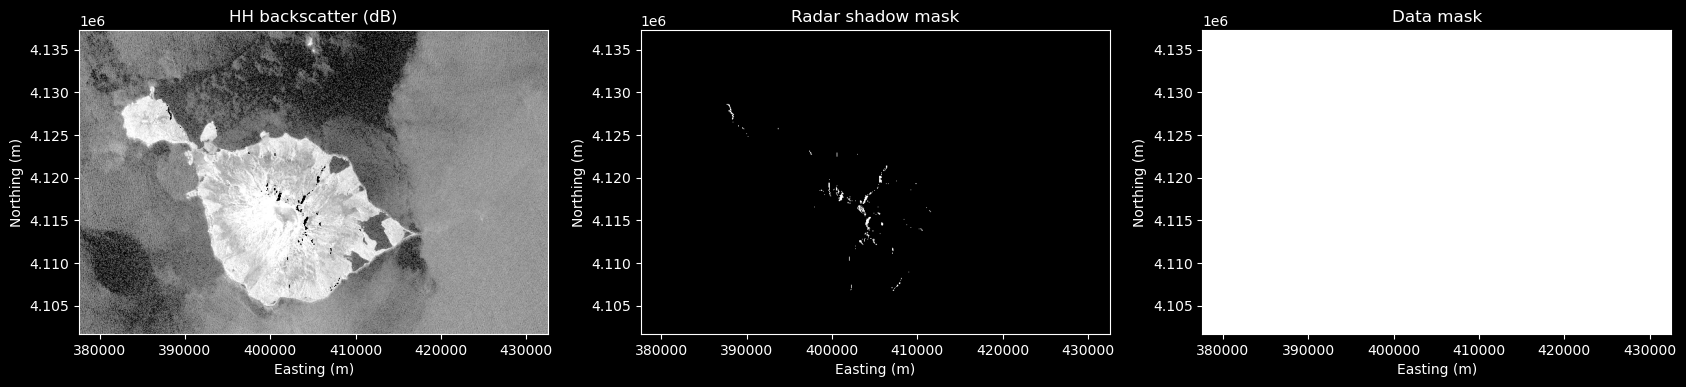

In [28]:
## Preview the full-island 2026 IW mosaic

# Read a reduced preview rather than the full raster into memory.

with rasterio.open(output_path) as source:
    preview_height = max(1, source.height // 8)
    preview_width = max(1, source.width // 8)

    preview = source.read(
        out_shape = (3, preview_height, preview_width))

    plot_extent = (
        source.bounds.left,
        source.bounds.right,
        source.bounds.bottom,
        source.bounds.top)

hh, shadow, data = preview
valid = data > 0.5

if not valid.any():
    raise RuntimeError("The mosaic contains no valid data")

hh_values = hh[valid & np.isfinite(hh) & (hh > -90)]
vmin, vmax = np.percentile(hh_values, [2, 98])

print(f"Valid data in AOI: {valid.mean():.1%}")
print(f"Radar shadow within valid data: {(shadow[valid] > 0.5).mean():.1%}")

with plt.style.context("dark_background"):
    fig, axes = plt.subplots(1, 3, figsize = (17, 6))

    axes[0].imshow(
        np.ma.masked_where(~valid, hh),
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = vmin,
        vmax = vmax)
    axes[0].set_title("HH backscatter (dB)")

    axes[1].imshow(
        shadow,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[1].set_title("Radar shadow mask")

    axes[2].imshow(
        valid,
        extent = plot_extent,
        origin = "upper",
        cmap = "gray",
        vmin = 0,
        vmax = 1)
    axes[2].set_title("Data mask")

    for ax in axes:
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

    fig.tight_layout()
    plt.show()